# Mental Health in Tech Survey — Exploratory Data Analysis

**Project Type:** Exploratory Data Analysis (EDA)  
**Contribution:** Individual  
**Dataset:** Mental Health in Tech Survey  
**Prepared for:** Academic EDA Capstone Project

## Project Summary

This project performs Exploratory Data Analysis (EDA) on the Mental Health in Tech Survey dataset. The dataset contains responses from technology-sector survey participants about mental health treatment, family history of mental illness, workplace interference, employment status, and organizational support. The purpose of this project is to understand the distribution of responses and identify patterns that may help organizations improve workplace mental health initiatives.

The analysis begins with data loading and inspection. The dataset is examined through its first records, number of rows and columns, data types, duplicate records, missing values, descriptive statistics, and unique values. These steps help identify data-quality issues before visual analysis. The original dataset is preserved, while a separate cleaned copy is created for analysis.

During data cleaning, the timestamp field is converted into a datetime format. Missing values in selected categorical fields are replaced with meaningful labels such as `Unknown`, and missing comments are represented as `No comment`. Unrealistic age values are removed by keeping respondents between 18 and 100 years. Gender responses are standardized into three broad groups: Male, Female, and Other. This reduces inconsistent spellings and formats while preserving the overall meaning of the responses.

The visualization section contains fifteen charts. These charts examine gender distribution, treatment status, family history, willingness to seek help, self-employment, work interference, and relationships between treatment and other factors. A correlation heatmap and pair plot are also included to explore numerical relationships. Each chart is accompanied by an explanation of why it was selected, the insights observed, and the possible business impact.

The analysis shows that the dataset has 1,251 valid adult records after age cleaning. Male respondents are the largest group, while female and other categories have lower representation. Treatment responses are relatively balanced, although family history shows a noticeable relationship with treatment status. Respondents reporting a family history of mental illness are more frequently represented in the treatment group. Work interference also varies considerably, with treatment responses being more common among respondents who report that mental health sometimes, rarely, or often interferes with work.

These findings can help organizations understand employee support needs, improve awareness campaigns, provide confidential care options, and design more inclusive workplace mental health programs. However, the dataset is based on survey responses and has demographic imbalance, so the results should be interpreted as descriptive patterns rather than universal conclusions.

## GitHub Link
[View Project on GitHub](https://github.com/sahilvishwakarma0/mental-health-tech-eda)

## Problem Statement

Mental health concerns can affect employee well-being, productivity, workplace relationships, and job performance. Organizations need evidence-based insights into employees’ experiences with mental health treatment, workplace interference, family history, and available support. The problem is to analyze survey data and identify patterns that can guide more inclusive and supportive workplace mental health policies.

## Business Objective

The objective is to analyze mental health-related responses from technology-sector participants, identify important patterns in treatment and workplace support, and provide practical recommendations for organizations. The analysis should help decision-makers improve awareness programs, confidential support systems, employee assistance initiatives, and inclusive workplace policies.

## 1. Know Your Data

### Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

### Dataset Loading

In [ ]:
DATA_PATH = Path("survey.csv")

if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/survey.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "survey.csv was not found. Place the CSV file in the same folder as the notebook."
    )

df = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully.")

Dataset loaded successfully.


### Dataset First View

In [3]:
display(df.head())

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


### Dataset Rows & Columns Count

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1259
Number of columns: 27


### Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

#### Duplicate Values

In [6]:
print("Duplicate records:", df.duplicated().sum())

Duplicate records: 0


#### Missing Values/Null Values

In [7]:
missing_values = df.isnull().sum().sort_values(ascending=False)
display(missing_values[missing_values > 0].to_frame("Missing Count"))

,Missing Count
comments,1095
state,515
work_interfere,264
self_employed,18


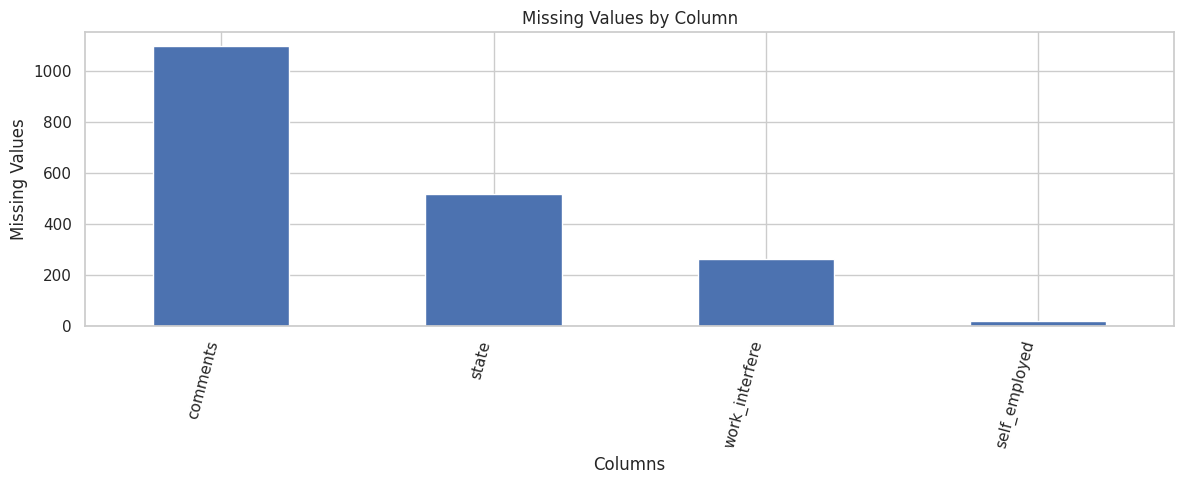

In [8]:
plt.figure(figsize=(12, 5))
missing_values[missing_values > 0].plot(kind="bar")
plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Missing Values")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

### What did you know about your dataset?

The dataset contains 1,259 records and 27 columns. It includes demographic information, employment characteristics, mental health treatment, family history, workplace interference, benefits, care options, anonymity, and workplace consequences. The initial inspection shows missing values in fields such as `state`, `self_employed`, `work_interfere`, and `comments`. The dataset also contains inconsistent gender labels and unrealistic age values, which require cleaning before analysis.

## 2. Understanding Your Variables

In [9]:
print("Dataset columns:")
for column in df.columns:
    print("-", column)

Dataset columns:
- Timestamp
- Age
- Gender
- Country
- state
- self_employed
- family_history
- treatment
- work_interfere
- no_employees
- remote_work
- tech_company
- benefits
- care_options
- wellness_program
- seek_help
- anonymity
- leave
- mental_health_consequence
- phys_health_consequence
- coworkers
- supervisor
- mental_health_interview
- phys_health_interview
- mental_vs_physical
- obs_consequence
- comments


In [10]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Timestamp,1259,1246,2014-08-27 12:31:41,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1259.0,NaN,NaN,NaN,79428148.311358,2818299442.981968,-1726.0,27.0,31.0,36.0,99999999999.0
Gender,1259,49,Male,615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,1259,48,United States,751,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,744,45,CA,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
self_employed,1241,2,No,1095,NaN,NaN,NaN,NaN,NaN,NaN,NaN
family_history,1259,2,No,767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
treatment,1259,2,Yes,637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_interfere,995,4,Sometimes,465,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_employees,1259,6,6-25,290,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

- **Timestamp:** Date and time when the response was recorded.
- **Age:** Age of the respondent.
- **Gender:** Gender reported by the respondent.
- **Country:** Country of the respondent.
- **state:** State or region, mainly for respondents in the United States.
- **self_employed:** Whether the respondent is self-employed.
- **family_history:** Whether the respondent has a family history of mental illness.
- **treatment:** Whether the respondent has sought treatment for a mental health condition.
- **work_interfere:** Frequency with which mental health interferes with work.
- **no_employees:** Approximate size of the respondent’s workplace.
- **remote_work:** Whether the respondent works remotely.
- **tech_company:** Whether the respondent works in a technology company.
- **benefits:** Whether mental health benefits are provided.
- **care_options:** Whether the respondent knows about available care options.
- **wellness_program:** Whether the workplace provides a wellness program.
- **seek_help:** Whether the workplace provides information about seeking help.
- **anonymity:** Whether the respondent believes anonymity is protected.
- **leave:** Ease of taking medical leave for a mental health condition.
- **mental_health_consequence:** Expected consequences of discussing mental health at work.
- **phys_health_consequence:** Expected consequences of discussing physical health at work.
- **coworkers:** Willingness to discuss mental health with coworkers.
- **supervisor:** Willingness to discuss mental health with a supervisor.
- **mental_health_interview:** Expected effect of discussing mental health during an interview.
- **phys_health_interview:** Expected effect of discussing physical health during an interview.
- **mental_vs_physical:** Whether mental health is treated differently from physical health.
- **obs_consequence:** Whether the respondent has observed negative consequences.
- **comments:** Additional comments.

### Check Unique Values for Each Variable

In [11]:
for column in df.columns:
    print(f"\n--- {column} ---")
    print(df[column].dropna().astype(str).value_counts().head(15))


--- Timestamp ---
Timestamp
2014-08-27 12:31:41    2
2014-08-28 16:52:34    2
2014-08-27 17:33:52    2
2014-08-27 12:54:11    2
2014-08-27 15:55:07    2
2014-08-27 12:37:50    2
2014-08-28 16:58:33    2
2014-08-28 09:59:39    2
2014-08-27 15:24:47    2
2014-08-27 14:22:43    2
2014-08-27 12:43:28    2
2014-08-27 12:44:51    2
2014-08-27 15:23:51    2
2014-08-28 16:56:57    1
2014-08-28 16:56:26    1
Name: count, dtype: int64

--- Age ---
Age
29    85
32    82
26    75
27    71
33    70
28    68
31    67
34    65
30    63
25    61
35    55
23    51
24    46
37    43
38    39
Name: count, dtype: int64

--- Gender ---
Gender
Male              615
male              206
Female            121
M                 116
female             62
F                  38
m                  34
f                  15
Make                4
Male                3
Woman               3
Cis Male            2
Man                 2
Female              2
Female (trans)      2
Name: count, dtype: int64

--- Country 

anonymity
Don't know    819
Yes           375
No             65
Name: count, dtype: int64

--- leave ---
leave
Don't know            563
Somewhat easy         266
Very easy             206
Somewhat difficult    126
Very difficult         98
Name: count, dtype: int64

--- mental_health_consequence ---
mental_health_consequence
No       490
Maybe    477
Yes      292
Name: count, dtype: int64

--- phys_health_consequence ---
phys_health_consequence
No       925
Maybe    273
Yes       61
Name: count, dtype: int64

--- coworkers ---
coworkers
Some of them    774
No              260
Yes             225
Name: count, dtype: int64

--- supervisor ---
supervisor
Yes             516
No              393
Some of them    350
Name: count, dtype: int64

--- mental_health_interview ---
mental_health_interview
No       1008
Maybe     207
Yes        44
Name: count, dtype: int64

--- phys_health_interview ---


phys_health_interview
Maybe    557
No       500
Yes      202
Name: count, dtype: int64

--- mental_vs_physical ---
mental_vs_physical
Don't know    576
Yes           343
No            340
Name: count, dtype: int64

--- obs_consequence ---
obs_consequence
No     1075
Yes     184
Name: count, dtype: int64

--- comments ---
comments
* Small family business - YMMV.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     5
I'm not on my company's health insurance which could be part of the reason I answered Don't know to so

## 3. Data Wrangling

### Data Wrangling Code

In [12]:
# Create a separate copy so the original dataset remains unchanged.
df_clean = df.copy()

# Convert timestamp into datetime format.
df_clean["Timestamp"] = pd.to_datetime(
    df_clean["Timestamp"],
    errors="coerce"
)

# Replace missing values with meaningful labels.
fill_values = {
    "state": "Unknown",
    "self_employed": "Unknown",
    "work_interfere": "Unknown",
    "comments": "No comment"
}

for column, value in fill_values.items():
    df_clean[column] = df_clean[column].fillna(value)

# Keep realistic adult ages only.
before_cleaning = len(df_clean)
df_clean = df_clean[
    (df_clean["Age"] >= 18) &
    (df_clean["Age"] <= 100)
].copy()
after_cleaning = len(df_clean)

# Standardize gender values into broad categories.
def clean_gender(value):
    if pd.isna(value):
        return "Other"

    value = str(value).strip().lower()

    male_values = {
        "male", "m", "man", "make", "mail", "mal", "cis male",
        "cis man", "male (cis)", "male-ish", "guy (-ish) ^_^",
        "male leaning androgynous", "nah"
    }

    female_values = {
        "female", "f", "woman", "femake", "female (cis)",
        "cis female", "cis-female/femme", "trans-female",
        "trans woman", "fem", "female (trans)", "femail"
    }

    if value in male_values or "male" in value and "female" not in value:
        return "Male"
    if value in female_values or "female" in value or "woman" in value:
        return "Female"

    return "Other"

df_clean["Gender_Clean"] = df_clean["Gender"].apply(clean_gender)

# Display cleaning results.
print("Rows before age cleaning:", before_cleaning)
print("Rows after age cleaning:", after_cleaning)
print("Rows removed:", before_cleaning - after_cleaning)
print("Total missing values after selected cleaning:", df_clean.isnull().sum().sum())
print("\nCleaned gender counts:")
print(df_clean["Gender_Clean"].value_counts())

Rows before age cleaning: 1259
Rows after age cleaning: 1251
Rows removed: 8
Total missing values after selected cleaning: 0

Cleaned gender counts:
Gender_Clean
Male      988
Female    251
Other      12
Name: count, dtype: int64


### What all manipulations have you done and insights you found?

1. Created `df_clean` as a separate copy to protect the original data.
2. Converted `Timestamp` into a datetime format.
3. Filled missing values in selected columns using `Unknown` or `No comment`.
4. Removed unrealistic age values by keeping ages from 18 to 100.
5. Standardized inconsistent gender responses into `Male`, `Female`, and `Other`.
6. Checked duplicates and missing values after cleaning.

The cleaning process reduced the dataset from 1,259 records to 1,251 records by removing eight unrealistic age records. The cleaned dataset is more suitable for descriptive analysis and visualization.

#### Chart - 1: Gender Distribution

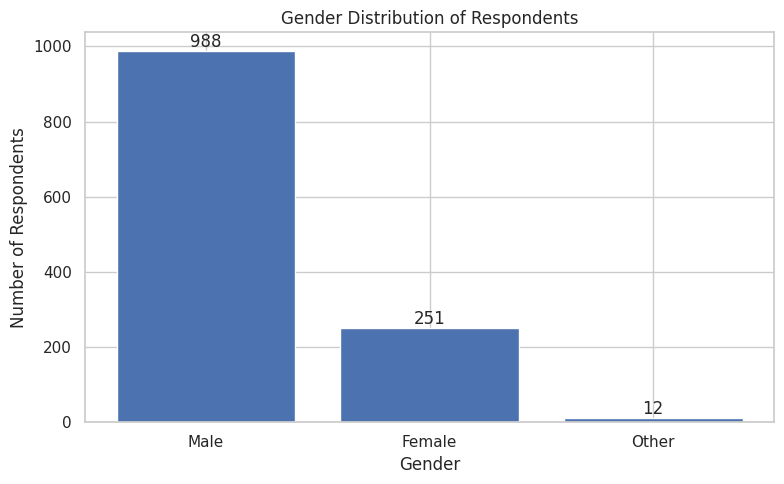

In [13]:
counts = df_clean["Gender_Clean"].value_counts()
plt.figure(figsize=(8, 5))
ax = plt.gca()
ax.bar(counts.index, counts.values)
for i, value in enumerate(counts.values):
    ax.text(i, value + 10, str(value), ha="center")
plt.title("Gender Distribution of Respondents")
plt.xlabel("Gender")
plt.ylabel("Number of Respondents")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is suitable for comparing the number of respondents across discrete gender categories.

##### 2. What is/are the insight(s) found from the chart?

Male respondents are the largest group, followed by Female and Other. The distribution is not balanced, so findings may reflect the experiences of the largest group more strongly.

##### 3. Will the gained insights help creating a positive business impact?

The chart helps organizations understand sample representation. Future surveys should encourage broader participation so that planning is more inclusive and representative.

#### Chart - 2: Mental Health Treatment Distribution

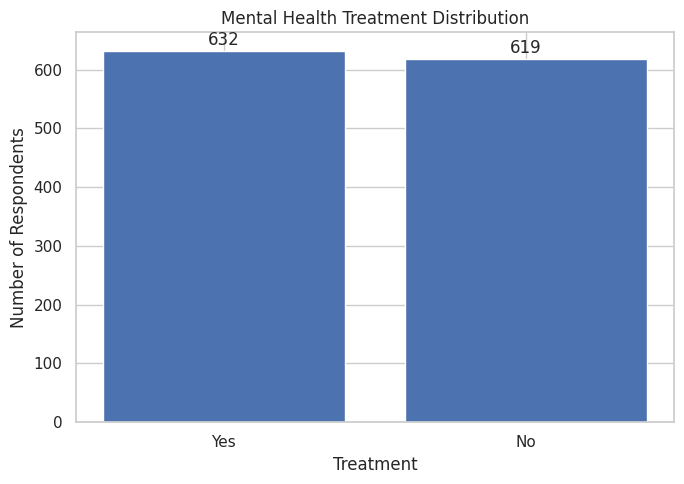

In [14]:
counts = df_clean["treatment"].value_counts()
plt.figure(figsize=(7, 5))
ax = plt.gca()
ax.bar(counts.index, counts.values)
for i, value in enumerate(counts.values):
    ax.text(i, value + 10, str(value), ha="center")
plt.title("Mental Health Treatment Distribution")
plt.xlabel("Treatment")
plt.ylabel("Number of Respondents")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart clearly compares the number of respondents who reported Yes or No for treatment.

##### 2. What is/are the insight(s) found from the chart?

Treatment responses are relatively balanced: 632 respondents reported Yes and 619 reported No.

##### 3. Will the gained insights help creating a positive business impact?

This insight can support planning for both treatment services and preventive mental health programs. Organizations should not assume that employees who have not sought treatment do not need support.

#### Chart - 3: Family History Distribution

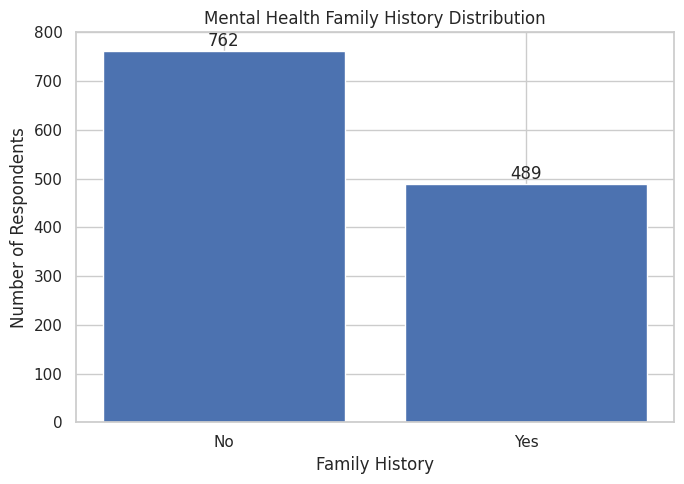

In [15]:
counts = df_clean["family_history"].value_counts()
plt.figure(figsize=(7, 5))
ax = plt.gca()
ax.bar(counts.index, counts.values)
for i, value in enumerate(counts.values):
    ax.text(i, value + 10, str(value), ha="center")
plt.title("Mental Health Family History Distribution")
plt.xlabel("Family History")
plt.ylabel("Number of Respondents")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is effective for comparing the Yes and No family-history categories.

##### 2. What is/are the insight(s) found from the chart?

There are 762 respondents with No family history and 489 with Yes family history.

##### 3. Will the gained insights help creating a positive business impact?

The result can encourage organizations to offer broad support rather than targeting only employees who report a family history. Mental health support should be available without requiring personal disclosure.

#### Chart - 4: Seeking Help Distribution

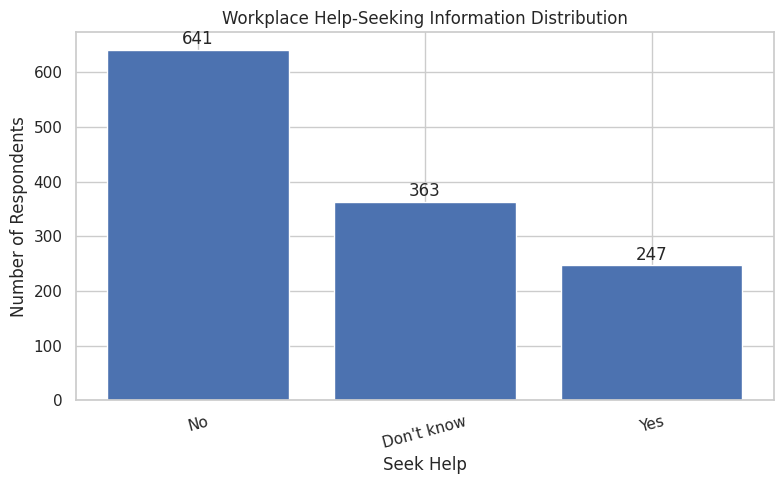

In [16]:
counts = df_clean["seek_help"].value_counts()
plt.figure(figsize=(8, 5))
ax = plt.gca()
ax.bar(counts.index, counts.values)
for i, value in enumerate(counts.values):
    ax.text(i, value + 10, str(value), ha="center")
plt.title("Workplace Help-Seeking Information Distribution")
plt.xlabel("Seek Help")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart allows direct comparison of the three response categories.

##### 2. What is/are the insight(s) found from the chart?

The most common response is No with 641 respondents, followed by Don't know with 363 and Yes with 247. A considerable group is uncertain about help-seeking information.

##### 3. Will the gained insights help creating a positive business impact?

Organizations can improve communication about available resources, employee assistance programs, and confidential support channels.

#### Chart - 5: Self-Employment Distribution

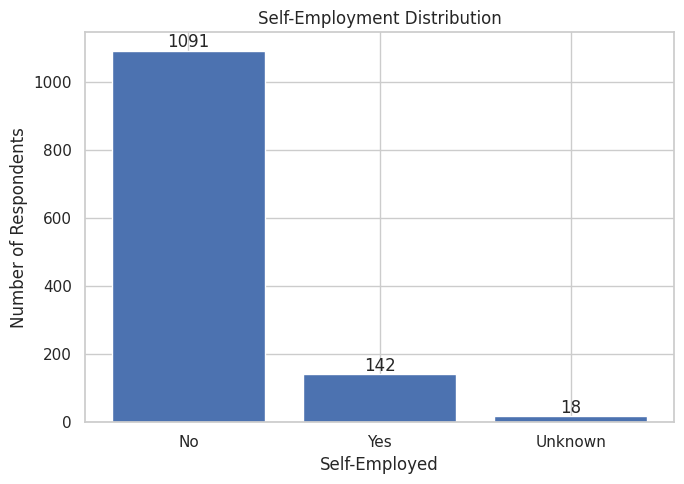

In [17]:
counts = df_clean["self_employed"].value_counts()
plt.figure(figsize=(7, 5))
ax = plt.gca()
ax.bar(counts.index, counts.values)
for i, value in enumerate(counts.values):
    ax.text(i, value + 10, str(value), ha="center")
plt.title("Self-Employment Distribution")
plt.xlabel("Self-Employed")
plt.ylabel("Number of Respondents")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is appropriate for comparing self-employed and non-self-employed respondents, including unknown values.

##### 2. What is/are the insight(s) found from the chart?

Most respondents are not self-employed: 1,091 reported No, 142 reported Yes, and 18 were Unknown.

##### 3. Will the gained insights help creating a positive business impact?

The finding helps describe the sample composition. Support policies should consider both employees and independent workers, although the dataset contains far more non-self-employed respondents.

#### Chart - 6: Work Interference Distribution

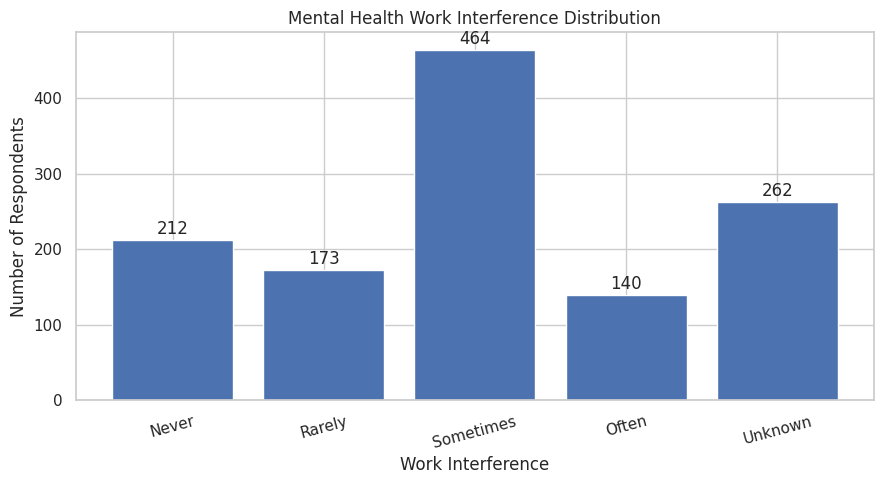

In [18]:
counts = df_clean["work_interfere"].value_counts()
order = ["Never", "Rarely", "Sometimes", "Often", "Unknown"]
counts = counts.reindex([x for x in order if x in counts.index])
plt.figure(figsize=(9, 5))
ax = plt.gca()
ax.bar(counts.index, counts.values)
for i, value in enumerate(counts.values):
    ax.text(i, value + 8, str(value), ha="center")
plt.title("Mental Health Work Interference Distribution")
plt.xlabel("Work Interference")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart compares how frequently respondents report that mental health interferes with work.

##### 2. What is/are the insight(s) found from the chart?

Sometimes is the largest known category with 464 respondents. Unknown has 262, Never has 212, Rarely has 173, and Often has 140.

##### 3. Will the gained insights help creating a positive business impact?

The result suggests that workplace mental health initiatives should include early support and flexible assistance because some respondents report occasional or frequent work interference.

#### Chart - 7: Family History vs Treatment

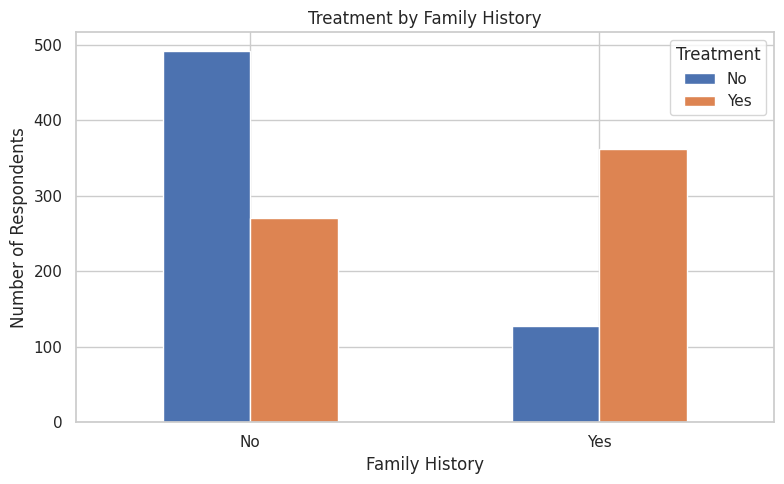

In [19]:
cross_tab = pd.crosstab(df_clean["family_history"], df_clean["treatment"])
cross_tab.plot(kind="bar", figsize=(8, 5))
plt.title("Treatment by Family History")
plt.xlabel("Family History")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=0)
plt.legend(title="Treatment")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart is suitable for comparing treatment responses within each family-history category.

##### 2. What is/are the insight(s) found from the chart?

Among respondents with No family history, 492 reported No treatment and 270 reported Yes. Among respondents with Yes family history, 127 reported No treatment and 362 reported Yes. This is a descriptive association, not proof of causation.

##### 3. Will the gained insights help creating a positive business impact?

The pattern can help organizations understand that employees with different backgrounds may have different support needs. Services should remain accessible to everyone and should not be based only on family history.

#### Chart - 8: Treatment by Work Interference

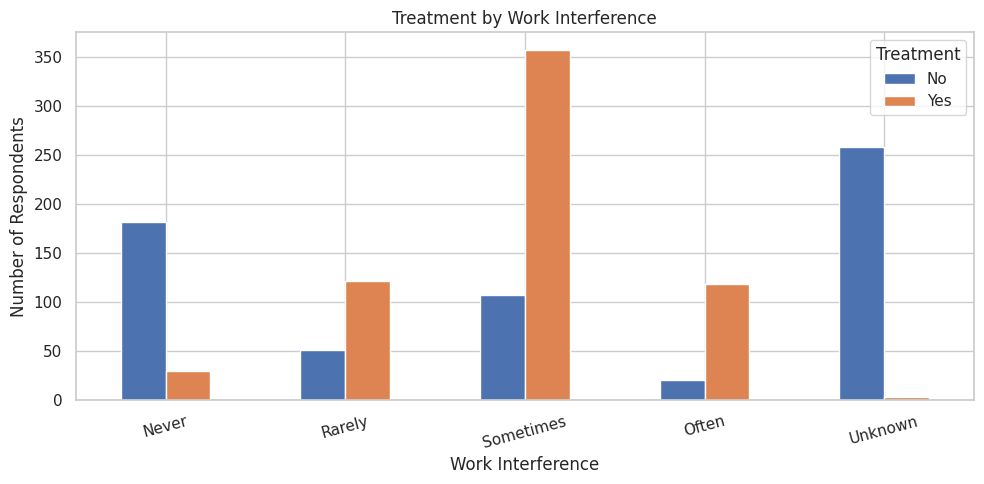

In [20]:
cross_tab = pd.crosstab(df_clean["work_interfere"], df_clean["treatment"])
order = [x for x in ["Never", "Rarely", "Sometimes", "Often", "Unknown"] if x in cross_tab.index]
cross_tab = cross_tab.reindex(order)
cross_tab.plot(kind="bar", figsize=(10, 5))
plt.title("Treatment by Work Interference")
plt.xlabel("Work Interference")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=15)
plt.legend(title="Treatment")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart compares treatment status across different work-interference frequencies.

##### 2. What is/are the insight(s) found from the chart?

Treatment Yes is especially common in the Sometimes and Often categories, while the Unknown category contains very few Yes responses. The pattern is descriptive and may be affected by missing or unreported information.

##### 3. Will the gained insights help creating a positive business impact?

The chart supports early intervention, manager training, and confidential support options for employees experiencing work-related difficulties.

#### Chart - 9: Treatment by Benefits

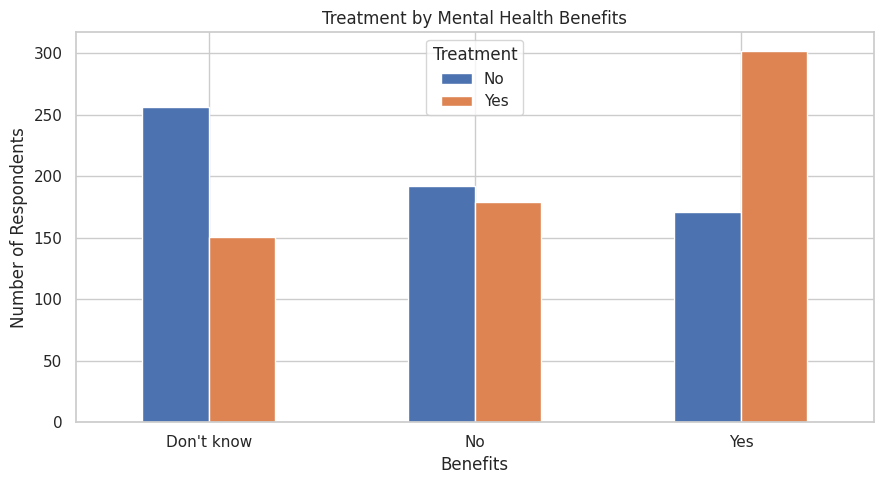

In [21]:
cross_tab = pd.crosstab(df_clean["benefits"], df_clean["treatment"])
cross_tab.plot(kind="bar", figsize=(9, 5))
plt.title("Treatment by Mental Health Benefits")
plt.xlabel("Benefits")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=0)
plt.legend(title="Treatment")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart compares treatment responses across benefits categories.

##### 2. What is/are the insight(s) found from the chart?

Treatment patterns vary across Yes, No, and Don't know benefits responses. The Don't know group indicates that some respondents may not be aware of the benefits provided.

##### 3. Will the gained insights help creating a positive business impact?

Organizations can improve the visibility and explanation of mental health benefits, while ensuring that benefits are accessible and confidential.

#### Chart - 10: Treatment by Care Options

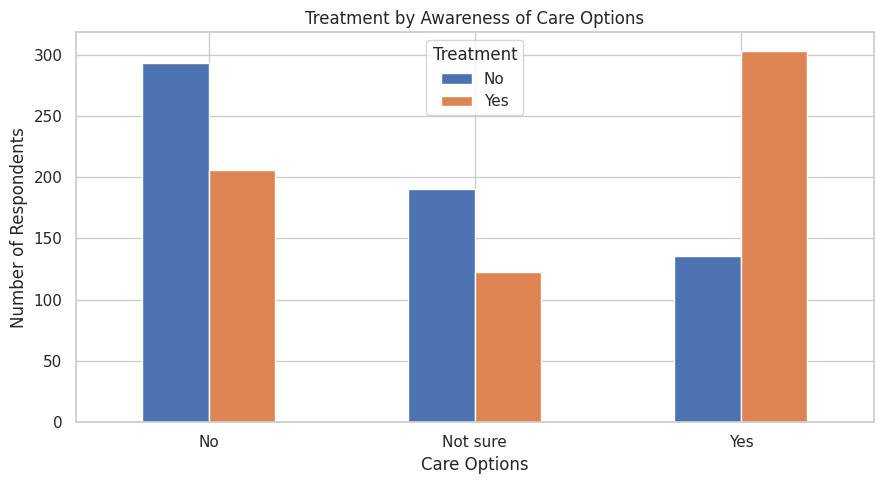

In [22]:
cross_tab = pd.crosstab(df_clean["care_options"], df_clean["treatment"])
cross_tab.plot(kind="bar", figsize=(9, 5))
plt.title("Treatment by Awareness of Care Options")
plt.xlabel("Care Options")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=0)
plt.legend(title="Treatment")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart compares treatment responses based on whether respondents know about available care options.

##### 2. What is/are the insight(s) found from the chart?

The chart shows differences in treatment responses among Yes, No, and Not sure categories. Uncertainty about care options is an important communication issue.

##### 3. Will the gained insights help creating a positive business impact?

Organizations can provide clear and repeated information about available care, contact points, and confidentiality procedures.

#### Chart - 11: Treatment by Anonymity

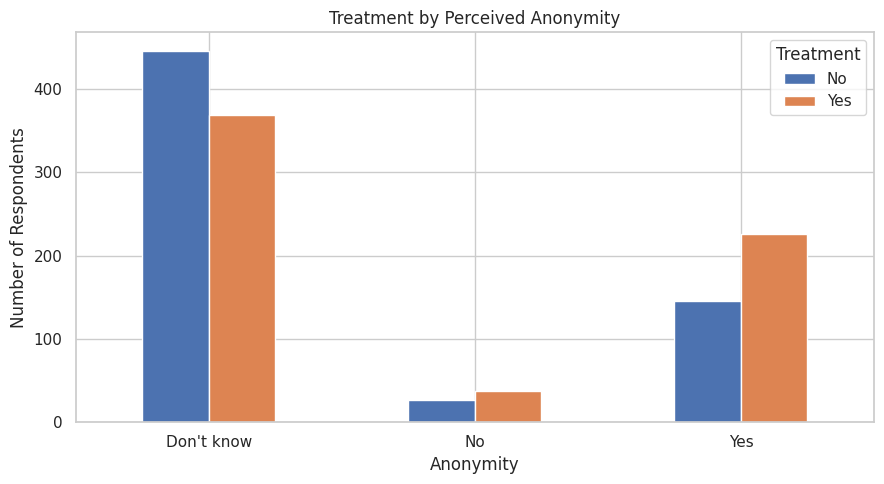

In [23]:
cross_tab = pd.crosstab(df_clean["anonymity"], df_clean["treatment"])
cross_tab.plot(kind="bar", figsize=(9, 5))
plt.title("Treatment by Perceived Anonymity")
plt.xlabel("Anonymity")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=0)
plt.legend(title="Treatment")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart is useful for comparing treatment responses across perceptions of anonymity.

##### 2. What is/are the insight(s) found from the chart?

Don't know is the largest anonymity category. This indicates that many respondents are uncertain about whether their privacy is protected.

##### 3. Will the gained insights help creating a positive business impact?

Clear privacy policies and confidential access procedures may increase trust in workplace mental health resources.

#### Chart - 12: Treatment by Technology Company Status

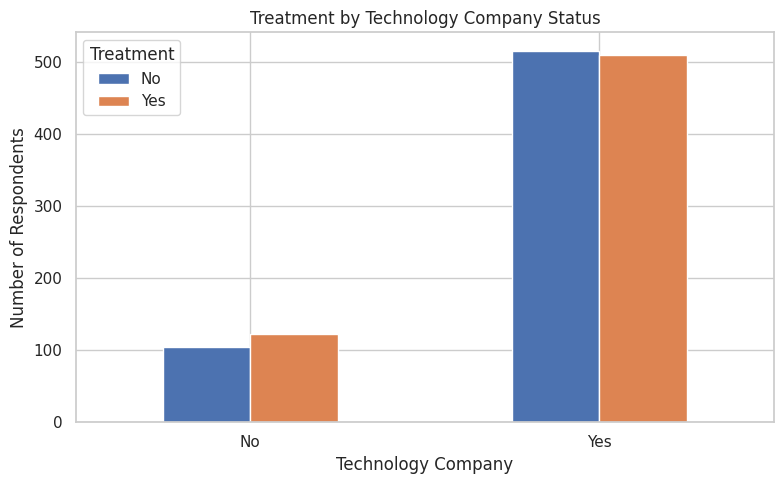

In [24]:
cross_tab = pd.crosstab(df_clean["tech_company"], df_clean["treatment"])
cross_tab.plot(kind="bar", figsize=(8, 5))
plt.title("Treatment by Technology Company Status")
plt.xlabel("Technology Company")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=0)
plt.legend(title="Treatment")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart compares treatment responses between technology-company and non-technology-company respondents.

##### 2. What is/are the insight(s) found from the chart?

Most respondents work in technology companies, so the overall pattern is strongly influenced by that group.

##### 3. Will the gained insights help creating a positive business impact?

The insight helps describe the sample and can guide sector-specific discussions, but the result should not be generalized to every industry.

#### Chart - 13: Treatment by Remote Work

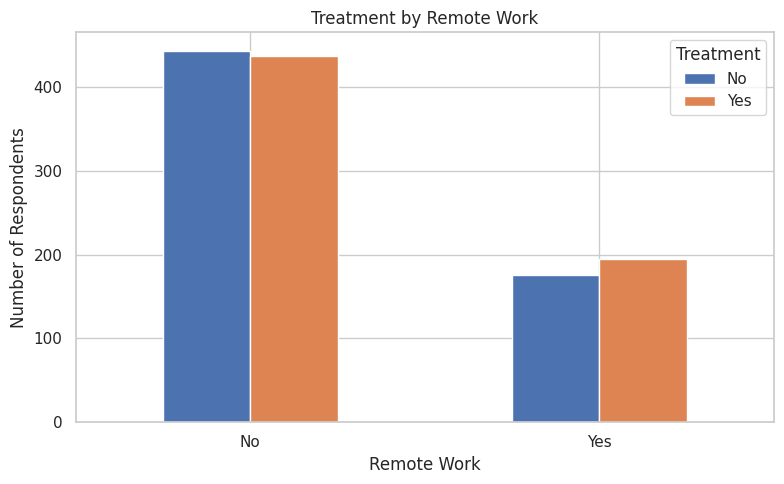

In [25]:
cross_tab = pd.crosstab(df_clean["remote_work"], df_clean["treatment"])
cross_tab.plot(kind="bar", figsize=(8, 5))
plt.title("Treatment by Remote Work")
plt.xlabel("Remote Work")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=0)
plt.legend(title="Treatment")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart compares treatment status for respondents who do and do not work remotely.

##### 2. What is/are the insight(s) found from the chart?

The chart shows treatment differences between remote and non-remote respondents. The result describes the sample and does not establish that remote work causes treatment differences.

##### 3. Will the gained insights help creating a positive business impact?

Organizations can consider both remote and office-based employees when designing communication, access, and support programs.

#### Chart - 14: Correlation Heatmap

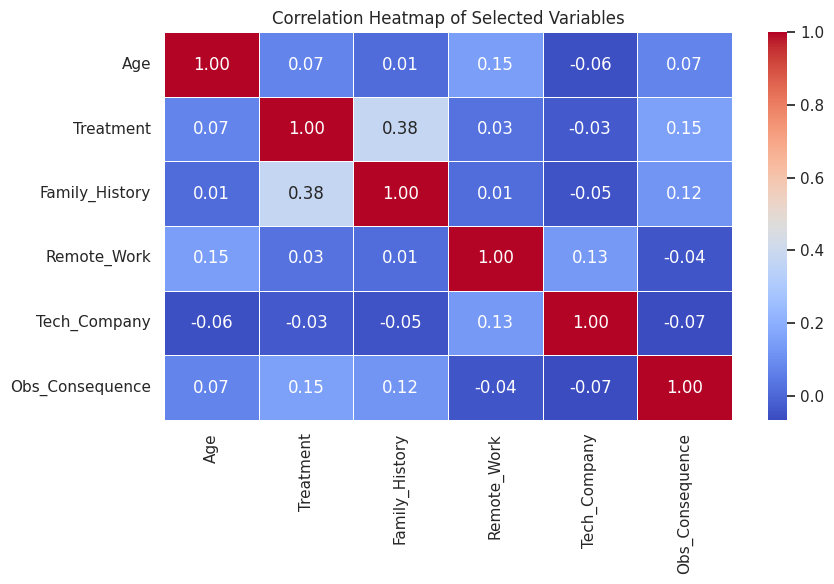

In [26]:
# Encode selected binary/categorical variables for a correlation overview.
numeric_view = pd.DataFrame({
    "Age": df_clean["Age"],
    "Treatment": df_clean["treatment"].map({"Yes": 1, "No": 0}),
    "Family_History": df_clean["family_history"].map({"Yes": 1, "No": 0}),
    "Remote_Work": df_clean["remote_work"].map({"Yes": 1, "No": 0}),
    "Tech_Company": df_clean["tech_company"].map({"Yes": 1, "No": 0}),
    "Obs_Consequence": df_clean["obs_consequence"].map({"Yes": 1, "No": 0})
}).dropna()

plt.figure(figsize=(9, 6))
sns.heatmap(numeric_view.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Selected Variables")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap provides a compact view of relationships between selected numerical and binary-encoded variables. It makes positive, negative, and weak relationships easier to compare.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows the strength and direction of pairwise correlations among age, treatment, family history, remote work, technology-company status, and observed consequences. Correlation values should be interpreted as associations and not as evidence of causation.

##### 3. Will the gained insights help creating a positive business impact?

Yes. The heatmap can help identify variables that deserve deeper analysis. Organizations can use these patterns to form better questions for future surveys, but should avoid making employee-level decisions from correlation alone.

#### Chart - 15: Pair Plot

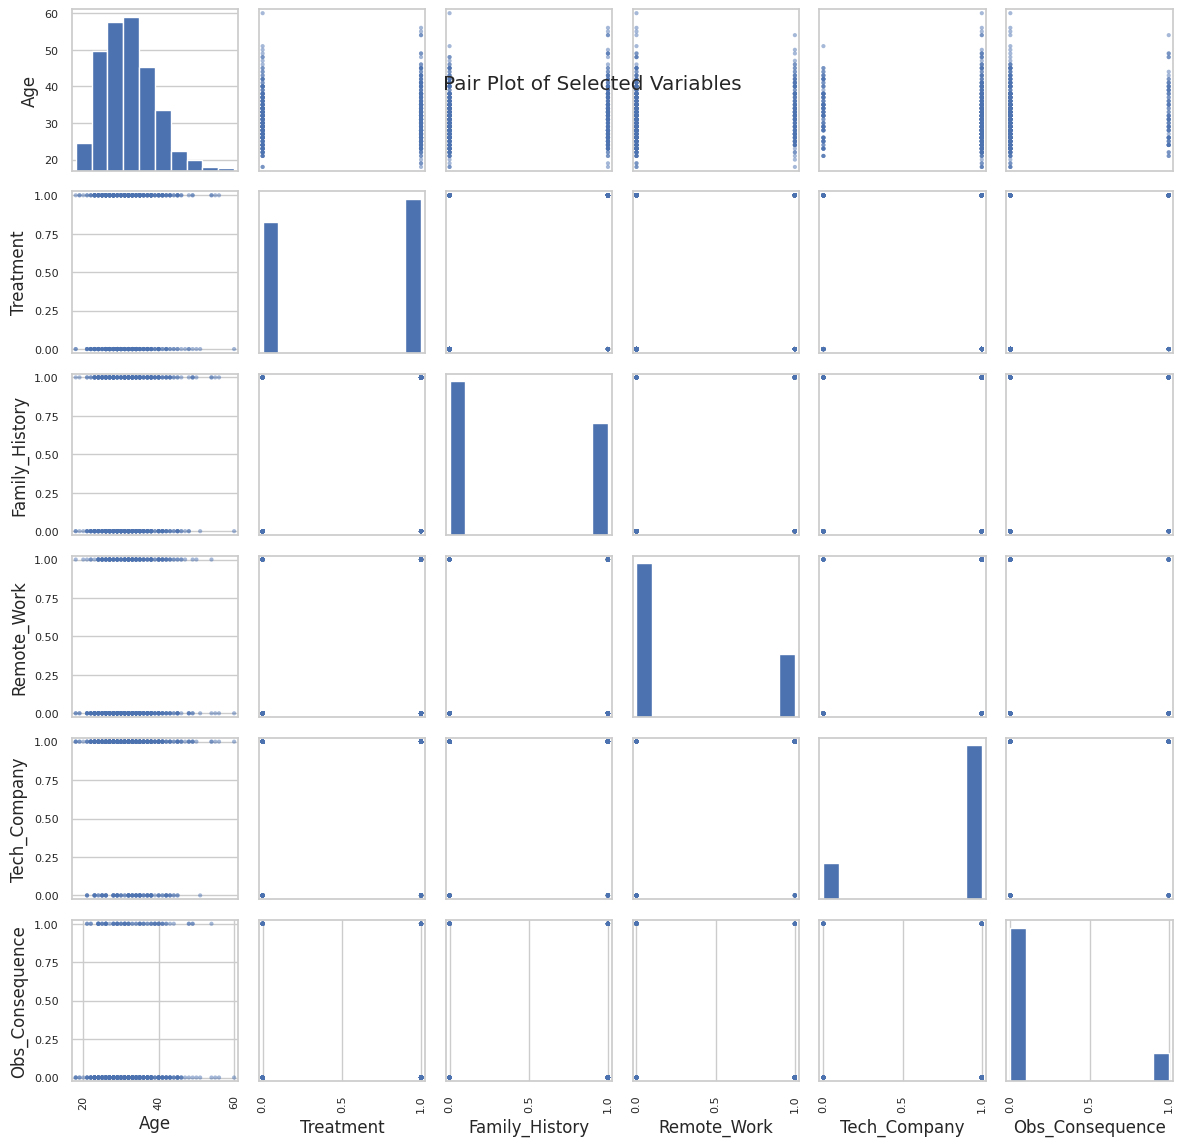

In [27]:
pair_data = numeric_view.sample(
    n=min(500, len(numeric_view)),
    random_state=42
)

pd.plotting.scatter_matrix(
    pair_data,
    figsize=(12, 12),
    diagonal="hist",
    alpha=0.5
)
plt.suptitle("Pair Plot of Selected Variables", y=0.90)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A pair plot displays distributions and pairwise relationships between selected variables. It is useful for spotting patterns, clusters, and unusual observations.

##### 2. What is/are the insight(s) found from the chart?

The pair plot provides a visual comparison of age, treatment, family history, remote work, technology-company status, and observed consequences. Binary variables form separate groups, while age shows its distribution across the sample.

##### 3. Will the gained insights help creating a positive business impact?

The chart can support exploratory questioning and help identify relationships that may need additional statistical analysis. It should be used for investigation rather than making causal or individual-level conclusions.

#### Chart - 16: Treatment by Gender

This chart compares mental health treatment responses across the cleaned gender categories.


In [ ]:
gender_treatment = pd.crosstab(df_clean['Gender_Clean'], df_clean['treatment']).reindex(columns=['Yes','No'], fill_value=0)
gender_treatment.plot(kind='bar', figsize=(9,5))
plt.title('Mental Health Treatment by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Treatment')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A grouped bar chart makes it easy to compare treatment responses among gender categories.

##### 2. What is/are the insight(s) found from the chart?

The chart highlights differences in treatment responses between the gender groups. The groups are not equally sized, so counts should be interpreted alongside group size.

##### 3. Will the gained insights help creating a positive business impact?

The comparison can help organizations check whether mental health communication and support are reaching different employee groups.


#### Chart - 17: Treatment by Age Group

Age bands provide a clearer comparison than plotting every individual age.


In [ ]:
df_clean['Age_Group'] = pd.cut(df_clean['Age'], bins=[17, 25, 35, 45, 55, 100], labels=['18-25','26-35','36-45','46-55','56+'])
age_treatment = pd.crosstab(df_clean['Age_Group'], df_clean['treatment']).reindex(columns=['Yes','No'], fill_value=0)
age_treatment.plot(kind='bar', figsize=(10,5))
plt.title('Mental Health Treatment by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Treatment')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Age groups reduce visual clutter and make it easier to compare treatment patterns across life stages.

##### 2. What is/are the insight(s) found from the chart?

The chart shows how the distribution of treatment responses changes across age bands. Some bands contain fewer respondents than others.

##### 3. Will the gained insights help creating a positive business impact?

Organizations can use age-group comparisons to consider whether support communication is accessible to employees at different career stages.


#### Chart - 18: Treatment by Company Size


In [ ]:
size_treatment = pd.crosstab(df_clean['no_employees'], df_clean['treatment']).reindex(columns=['Yes','No'], fill_value=0)
size_treatment.plot(kind='bar', figsize=(11,5))
plt.title('Mental Health Treatment by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=35, ha='right')
plt.legend(title='Treatment')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Company size may shape the availability and visibility of workplace support, so a grouped comparison is useful.

##### 2. What is/are the insight(s) found from the chart?

Treatment responses vary across company-size categories, and the category counts are different. This is a descriptive comparison rather than a causal conclusion.

##### 3. Will the gained insights help creating a positive business impact?

The result can help organizations think about support models for both small and large workplaces.


#### Chart - 19: Treatment by Technology Company Status


In [ ]:
tech_treatment = pd.crosstab(df_clean['tech_company'], df_clean['treatment']).reindex(columns=['Yes','No'], fill_value=0)
tech_treatment.plot(kind='bar', figsize=(8,5))
plt.title('Mental Health Treatment by Technology Company Status')
plt.xlabel('Technology Company')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Treatment')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

This chart compares respondents from technology and non-technology companies.

##### 2. What is/are the insight(s) found from the chart?

The chart shows the treatment distribution for the two company-status groups, while the sample sizes should be considered.

##### 3. Will the gained insights help creating a positive business impact?

The comparison can help organizations consider whether mental health resources are communicated consistently across different business environments.


#### Chart - 20: Remote Work and Work Interference


In [ ]:
remote_interference = pd.crosstab(df_clean['remote_work'], df_clean['work_interfere']).reindex(columns=['Never','Rarely','Sometimes','Often','Unknown'], fill_value=0)
remote_interference.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title('Remote Work Status and Work Interference')
plt.xlabel('Remote Work')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Work Interference', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A stacked bar chart shows the composition of work-interference responses within remote-work groups.

##### 2. What is/are the insight(s) found from the chart?

The composition of work-interference categories differs across remote-work responses. Missing or unknown values are shown explicitly where available.

##### 3. Will the gained insights help creating a positive business impact?

Organizations can use this comparison to include both remote and non-remote employees in workplace well-being planning.


## 5. Solution to Business Objective

Organizations should use the findings to improve workplace mental health support through the following actions:

1. **Improve awareness:** Clearly communicate available mental health benefits, care options, and help-seeking channels.
2. **Protect confidentiality:** Explain anonymity and privacy procedures in simple language.
3. **Provide early support:** Offer accessible resources before mental health concerns begin to interfere frequently with work.
4. **Train managers:** Teach supervisors how to respond respectfully and direct employees to appropriate support.
5. **Use inclusive programs:** Ensure that support is available across gender groups, employment types, remote workers, and different workplace sizes.
6. **Collect better data:** Repeat surveys with balanced participation and clearly defined questions to reduce uncertainty and demographic imbalance.
7. **Avoid stigma:** Build a culture where requesting support does not negatively affect career opportunities or workplace relationships.

These recommendations are based on descriptive patterns in the survey and should be validated with current organizational data before implementation.

# Conclusion

This project analyzed the Mental Health in Tech Survey dataset using exploratory data analysis. The original dataset contained 1,259 records and 27 columns. After cleaning unrealistic age values, the analysis dataset contained 1,251 records. Missing values were handled in selected fields, inconsistent gender responses were standardized, and the original dataset was preserved.

The visual analysis examined respondent demographics, treatment status, family history, help-seeking awareness, self-employment, work interference, and relationships between treatment and workplace-related factors. The analysis indicates that family history and work interference show noticeable differences across treatment categories. It also highlights uncertainty about mental health benefits, care options, and anonymity.

The findings can support workplace awareness programs, confidential care options, manager training, and inclusive mental health policies. However, the dataset is observational and contains demographic imbalance and missing or uncertain responses. Therefore, the results should be treated as descriptive insights rather than causal conclusions. Future analysis can include statistical testing, more balanced data collection, and comparison with newer surveys.